# Appendix — hybrid parameterization sanity check

A controlled pendulum example used to test the hybrid idea before the ocean-column experiment:
keep the known dynamical core and learn only the unresolved drag term.

In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

rng = np.random.default_rng(0)

## 1. Controlled system

\[
\dot\theta=\omega,\qquad
\dot\omega=-\frac{g}{L}\sin\theta-k\,\omega|\omega|.
\]

The gravity term is treated as known physics; the nonlinear drag is the closure to be represented.

In [3]:
G_OVER_L = 9.81
K_DRAG = 0.50

def core_accel(theta):
    return -G_OVER_L * np.sin(theta)

def true_accel(theta, omega):
    return core_accel(theta) - K_DRAG * omega * np.abs(omega)

def integrate(accel_fn, theta0, omega0, dt, n):
    th = np.empty(n + 1)
    om = np.empty(n + 1)
    th[0], om[0] = theta0, omega0

    for i in range(n):
        def deriv(t, w):
            return w, accel_fn(t, w)

        k1 = deriv(th[i], om[i])
        k2 = deriv(th[i] + 0.5*dt*k1[0], om[i] + 0.5*dt*k1[1])
        k3 = deriv(th[i] + 0.5*dt*k2[0], om[i] + 0.5*dt*k2[1])
        k4 = deriv(th[i] + dt*k3[0], om[i] + dt*k3[1])

        th[i+1] = th[i] + dt/6 * (k1[0] + 2*k2[0] + 2*k3[0] + k4[0])
        om[i+1] = om[i] + dt/6 * (k1[1] + 2*k2[1] + 2*k3[1] + k4[1])

    return th, om

## 2. Train the parameterizations

Training trajectories use moderate initial amplitudes. The hybrid model learns only the residual drag, while the black-box model learns the full acceleration.

In [4]:
dt, T = 0.02, 20.0
n_steps = int(T / dt)
train_ics = [0.4, 0.6, 0.8, 1.0, 1.2]

TH, OM, ACC = [], [], []
for th0 in train_ics:
    th, om = integrate(true_accel, th0, 0.0, dt, n_steps)
    TH.append(th)
    OM.append(om)
    ACC.append(true_accel(th, om))

TH = np.concatenate(TH)
OM = np.concatenate(OM)
ACC = np.concatenate(ACC)

X = np.column_stack([TH, OM])
DRAG = ACC - core_accel(TH)

# Conventional linear-drag baseline
c_lin = -np.sum(DRAG * OM) / np.sum(OM**2)

# Black-box model: full acceleration
nn_full = make_pipeline(
    StandardScaler(),
    MLPRegressor(
        hidden_layer_sizes=(64, 64),
        activation="tanh",
        max_iter=4000,
        random_state=0,
    ),
)
nn_full.fit(X, ACC)

# Hybrid model: drag residual only
nn_drag = make_pipeline(
    StandardScaler(),
    MLPRegressor(
        hidden_layer_sizes=(32, 32),
        activation="tanh",
        max_iter=4000,
        random_state=0,
    ),
)
nn_drag.fit(X, DRAG)

def m_physics(t, w):
    return core_accel(t)

def m_classic(t, w):
    return core_accel(t) - c_lin * w

def m_pureml(t, w):
    return float(nn_full.predict([[t, w]])[0])

def m_hybrid(t, w):
    return core_accel(t) + float(nn_drag.predict([[t, w]])[0])

models = {
    "physics only": m_physics,
    "linear parameterization": m_classic,
    "black-box ML": m_pureml,
    "hybrid": m_hybrid,
}

print("training samples:", len(X))
print(f"linear-drag baseline c = {c_lin:.4f}")

training samples: 5005
linear-drag baseline c = 0.6132


## 3. Held-out trajectory

Test at a larger initial angle than any training trajectory.

In [5]:
theta0_test = 2.5
th_true, _ = integrate(true_accel, theta0_test, 0.0, dt, n_steps)

results = {}
print(f"{'model':<26}{'theta RMSE':>12}")
print("-" * 38)

for name, fn in models.items():
    th_m, _ = integrate(fn, theta0_test, 0.0, dt, n_steps)
    rmse = np.sqrt(np.mean((th_m - th_true)**2))
    results[name] = (th_m, rmse)
    print(f"{name:<26}{rmse:>12.4f}")

model                       theta RMSE
--------------------------------------
physics only                    1.8228
linear parameterization         0.1800
black-box ML                    0.1603
hybrid                          0.1179


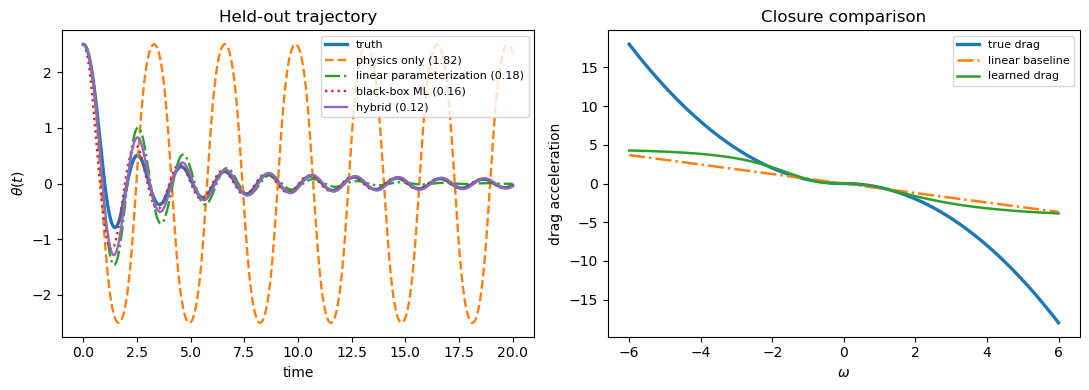

In [6]:
t = np.arange(n_steps + 1) * dt
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].plot(t, th_true, lw=2.4, label="truth")
line_styles = ["--", "-.", ":", "-"]
for (name, (th_m, rmse)), ls in zip(results.items(), line_styles):
    ax[0].plot(t, th_m, ls=ls, lw=1.7, label=f"{name} ({rmse:.2f})")
ax[0].set_xlabel("time")
ax[0].set_ylabel(r"$\theta(t)$")
ax[0].set_title("Held-out trajectory")
ax[0].legend(fontsize=8)

w = np.linspace(-6, 6, 200)
Xg = np.column_stack([np.zeros_like(w), w])
ax[1].plot(w, -K_DRAG*w*np.abs(w), lw=2.4, label="true drag")
ax[1].plot(w, -c_lin*w, ls="-.", lw=1.8, label="linear baseline")
ax[1].plot(w, nn_drag.predict(Xg), lw=1.8, label="learned drag")
ax[1].set_xlabel(r"$\omega$")
ax[1].set_ylabel("drag acceleration")
ax[1].set_title("Closure comparison")
ax[1].legend(fontsize=8)

fig.tight_layout()
plt.show()

**Takeaway:** this is only a controlled sanity check. The ocean-column notebook is the main physics–ML example.